# TORCS Training

In [ ]:
import os
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [2]:
CHECKPOINT_DIR = "checkpoints"

AVG_FILTER_SIZE = 100
ALPHA_MEAN=0.9
ALPHA_STD =0.2

TRAIN_COLOR = "BLUE"
VAL_COLOR = "ORANGE"

TRAIN_TRACKS = {
    "alpine-1",
    "aalborg",
    "street-1",
    "forza",
    "wheel-1",
    "wheel-2",
}

VAL_TRACKS = {
    "g-track-1",
    "g-track-2",
    "ruudskogen",
    "alpine-2",
}

TRACK_ORDER = [
    "alpine-1",
    "aalborg",
    "street-1",
    "forza",
    "wheel-1",
    "wheel-2",

    "g-track-2",
    "brondehach",
    "alpine-2",
]

ALG_COLORS = {"nstepddpg": "blue", "nsteptd3": "green", "nstepsac": "purple"}
ALG_NAMES = {"nstepddpg": "N-Step DDPG", "nsteptd3": "N-Step TD3"}

In [3]:
def collect_runs_over_seed(algorithm: str) -> dict[str, pd.DataFrame]:
    path = os.path.join(CHECKPOINT_DIR, algorithm)

    data = defaultdict(list)

    for run in os.listdir(path):
        run_path = os.path.join(path, run)

        for csv_file in os.listdir(run_path):
            if not csv_file.endswith(".csv"):
                continue

            track_name = csv_file.split("_", 3)[-1].replace(".csv", "")

            df = pd.read_csv(os.path.join(run_path, csv_file))
            df = df.drop(columns=["std_return"])
            df["timesteps"] = (df["timesteps"] // 10_000) / 100
            data[track_name].append(df)

    aggregated = {}

    for track_name, dfs in data.items():
        combined = pd.concat(dfs, ignore_index=True)

        aggregated[track_name] = (
            combined
            .groupby("timesteps", as_index=False)
            .agg(
                mean_return=("average_return", "mean"),
                std_return=("average_return", "std"),
                mean_speed=("average_speed", "mean"),
                std_speed=("average_speed", "std"),
                mean_lap_time=("lap_time", "mean")
            )
            .sort_values("timesteps")
        )

    return aggregated

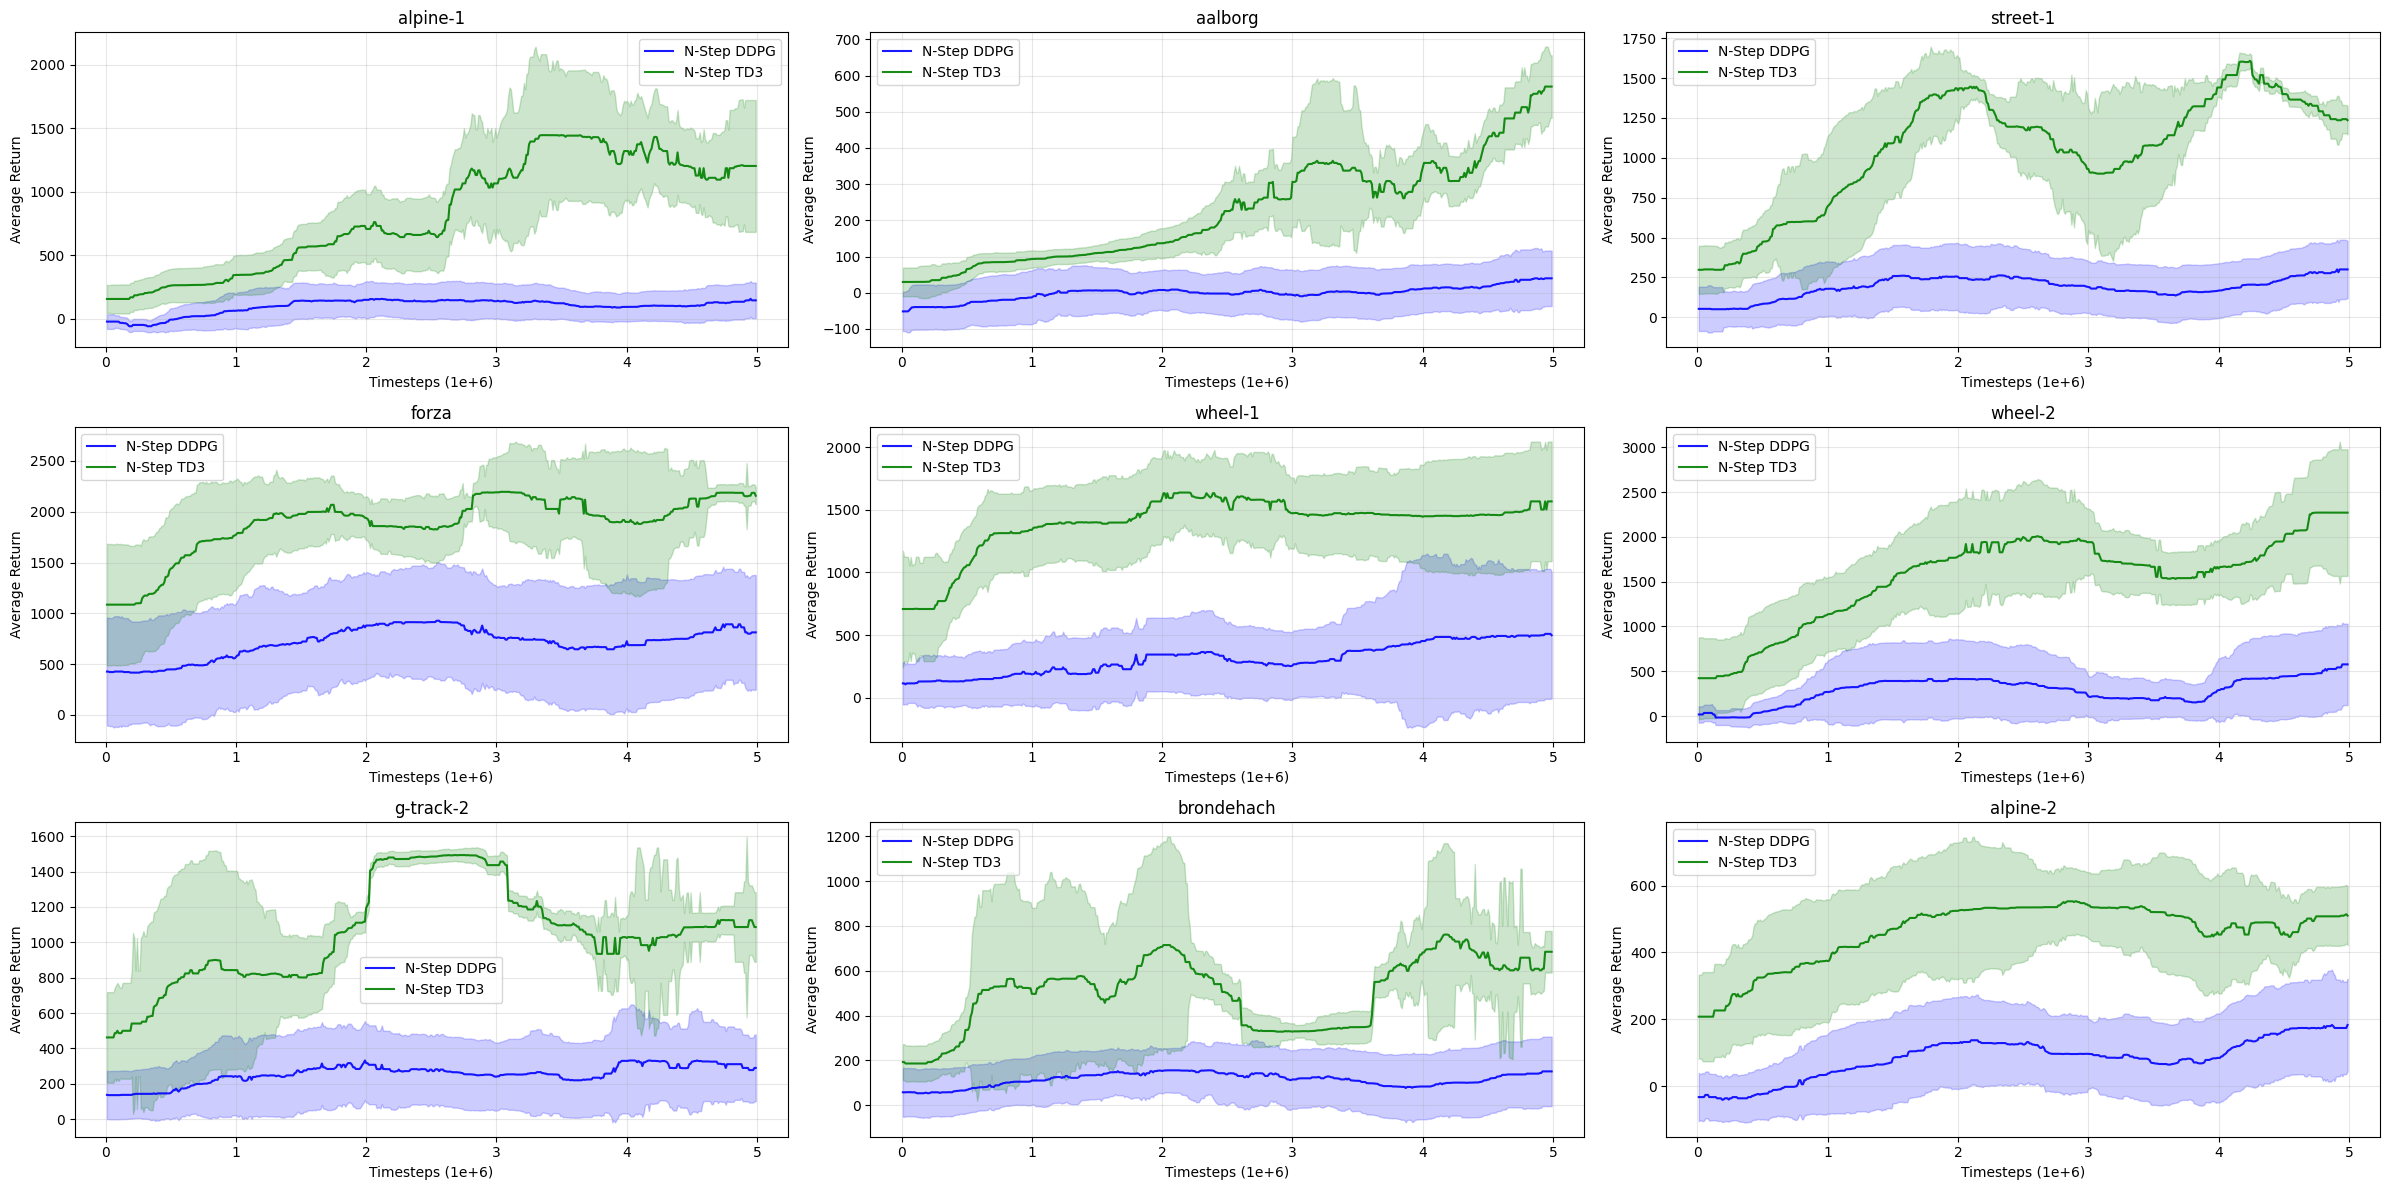

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(24, 12))
ax = ax.flatten()

for alg in ALG_NAMES.keys():
    dfs = collect_runs_over_seed(alg)

    for i, track_name in enumerate(TRACK_ORDER):
        data = dfs[track_name]

        t = data["timesteps"]

        mean = scipy.ndimage.median_filter(
            data["mean_return"],
            size=AVG_FILTER_SIZE,
         )

        std = scipy.ndimage.median_filter(
            data["std_return"].fillna(0),
            size=AVG_FILTER_SIZE,
        )

        lower = mean - std
        upper = mean + std

        ax[i].plot(
            t,
            mean,
            label=ALG_NAMES[alg],
            color=ALG_COLORS[alg],
            alpha=ALPHA_MEAN,
        )

        ax[i].fill_between(
            t,
            lower,
            upper,
            color=ALG_COLORS[alg],
            alpha=ALPHA_STD,
        )

        ax[i].set_title(track_name)
        ax[i].set_xlabel("Timesteps (1e+6)")
        ax[i].set_ylabel("Average Return")
        ax[i].grid(alpha=0.3)
        ax[i].legend()

plt.tight_layout()
plt.show()